**Email spam Detection with Machine Learning**

A Machine Learning project that detects spam emails using Natural Language Processing (NLP) and classification algorithms. Includes text preprocessing, data visualization, model training, evaluation, and an interactive Streamlit app for real-time spam prediction.

**Step 1: Import Libraries**

In [2]:
import pandas as pd #file read and data manipulation
import numpy as np #for numeric calculations
import matplotlib.pyplot as plt #for data visualization
import seaborn as sns #for advance data visualization
import nltk #for NLP and text preprocessing
import string #for handling punctuation and special characters
from nltk.corpus import stopwords #for small value words removal
from sklearn.feature_extraction.text import TfidfVectorizer #for extracting imp words
from sklearn.model_selection import train_test_split #for spliting dataset into train and test sets
from sklearn.naive_bayes import MultinomialNB #algorithm for text classification
from sklearn.metrics import accuracy_score, classification_report #for evaluating model performance
import joblib #to save and load model

## Libraries Used in Email Spam Detection Project

## NLTK
Used for text preprocessing like tokenization and removing stopwords.

## string
Used to remove punctuation and special characters from text.

## stopwords
Used to remove common unnecessary words like "is", "the", "and".

## TfidfVectorizer
Converts text data into numerical values using TF-IDF so the ML model can understand text.

## train_test_split
Splits dataset into training and testing data.

## MultinomialNB
Naive Bayes machine learning algorithm used for spam classification.

## accuracy_score
Calculates model accuracy.

## classification_report
Shows detailed performance metrics like precision, recall, and F1-score.

## joblib
Used to save and load the trained machine learning model.

**Step 2: Load Dataset**

In [3]:
df = pd.read_csv('spam.csv', encoding = 'latin-1')

latin-1 is a text encoding format used to read special characters correctly and avoid encoding errors

In [4]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


**Step 3: Keep needed columns**

In [5]:
df_imp = df[['v1', 'v2']]
df_imp .columns = ['label', 'message']

Keeps only important columns

renames columns for simplicity

**Step 4: Create a copy of dataset**

In [6]:
df_copy = df_imp.copy()

**Step 5: Basic EDA**

In [7]:
print("First 5 rows: ")
df_imp.head()

First 5 rows: 


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
print("Last 5 rows: ")
df_imp.tail()

Last 5 rows: 


,label,message
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [9]:
print("Shape of dataset: ")
df_imp.shape

Shape of dataset: 


(5572, 2)

In [10]:
print("Columns information: ")
df_imp.columns

Columns information: 


Index(['label', 'message'], dtype='object')

In [11]:
print("Basic Information about dataset: ")
df_imp.info()

Basic Information about dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [12]:
print("Statistical Summary: ")
df_imp.describe()

Statistical Summary: 


,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


**Step 6: Check Missing Values**

In [13]:
df_imp.isnull().sum()

label      0
message    0
dtype: int64

## Insight:

dataset has no missing values

**Step 7: Label Count Visualization**

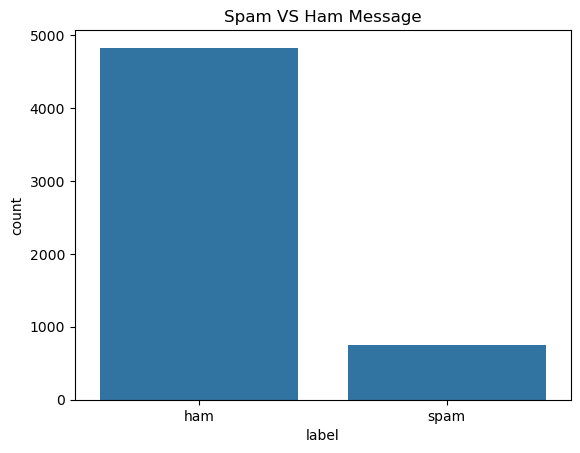

In [14]:
sns.countplot(x = df_copy['label'])
plt.title('Spam VS Ham Message')
plt.savefig('Spam_VS_Ham.png')
plt.show()

## Insight:

Ham messages are more than spam messages

**Step 8: Message Length**

In [15]:
df_copy['Msg_Length'] = df_copy['message'].apply(len)

**Step 9: Length Visualization**

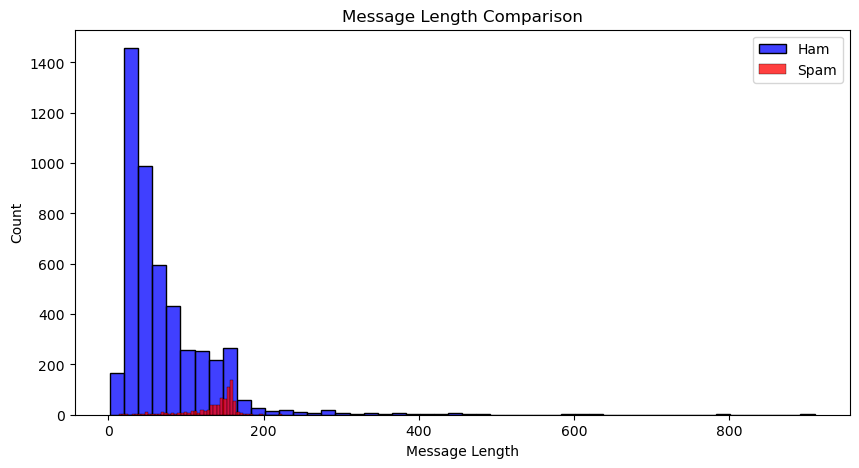

In [16]:
plt.figure(figsize = (10,5))
sns.histplot(df_copy[df_copy['label'] == 'ham']['Msg_Length'], color = 'blue', label = 'Ham', bins = 50)
sns.histplot(df_copy[df_copy['label'] == 'spam']['Msg_Length'], color = 'red', label = 'Spam', bins = 50)
plt.legend()
plt.title('Message Length Comparison')
plt.savefig('Message_Length_Comparison.png')
plt.xlabel('Message Length')
plt.ylabel('Count')
plt.show()

## Insight:

1. Spam messages are generally longer
2. Ham messages are shorter and more frequent

**Step 10: Convert labels to Numbers**

In [17]:
df_copy['label'] = df_copy['label'].map({'ham' : 0, 'spam' : 1})

as we know that ML models understand numbers better so here we have used ordinal encoding using mapping

**Step 11: Text Vectorization**

In [18]:
tfidf = TfidfVectorizer(stop_words = 'english')
x = tfidf.fit_transform(df_copy['message'])
y = df_copy['label']

Converts text into numbers

removes common useless words

x -> input features


y -> output features

**Step 12: Train Test Split**

In [19]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

**Step 13: Train Model**

In [38]:
model = MultinomialNB()
model.fit(x_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


Model learns spam patterns from messages

In [39]:
print('Model Training Completed')

Model Training Completed


**Step 14: Prediction**

In [40]:
y_prediction = model.predict(x_test)

**Step 15: Accuracy**

In [43]:
print(f'Accuracy: {round(accuracy_score(y_test, y_prediction) * 100, 2)} %')

Accuracy: 96.86 %


## Insight:

Higher accuracy means better spam detection

**Step 16: Save Model**

In [45]:
joblib.dump(model, 'spam_model.pkl')

['spam_model.pkl']

In [46]:
joblib.dump(tfidf, 'vectorizer.pkl')

['vectorizer.pkl']

**Step 17: Important Insights**

1. Most messages are not spam (ham).
2. Spam messages are usually longer.
3. Words like "Free", "Win", and "Prize" appear often in spam.
4. Ham messages are shorter and normal conversations.
5. NLP helps convert text into numerical data for prediction.
6. The model can accurately detect spam messages.